In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [12]:
import pandas as pd

df = pd.read_csv("Healthcare dataset( cleaned) 2 .csv")

In [13]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,length of stay days
0,aAroN ADaMS,38,Female,O-,Cancer,2021-03-10,Norma Li,Hart LLC,UnitedHealthcare,26052.11,363,Elective,2021-03-29,Lipitor,Inconclusive,19
1,aAROn aguIRRe,36,Male,A-,Diabetes,2023-02-26,Katrina Luna,Murray-Shelton,UnitedHealthcare,27087.56,300,Emergency,2023-03-13,Aspirin,Inconclusive,15
2,AArOn AnderSoN,50,Female,A+,Asthma,2020-12-18,Kenneth Jennings,Tanner-Cox,Cigna,39804.66,196,Urgent,2021-01-15,Aspirin,Inconclusive,28
3,aaRON AndeRSoN md,20,Female,A-,Hypertension,2021-03-28,Tammy Perez,Ritter LLC,UnitedHealthcare,16846.42,249,Elective,2021-04-09,Paracetamol,Abnormal,12
4,AAron ArCHER,47,Female,B-,Cancer,2021-01-10,Cynthia Villanueva,"Montes Case and Mendez,",Medicare,10602.08,108,Urgent,2021-01-17,Paracetamol,Inconclusive,7


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54860 entries, 0 to 54859
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 54860 non-null  object 
 1   Age                  54860 non-null  int64  
 2   Gender               54860 non-null  object 
 3   Blood Type           54860 non-null  object 
 4   Medical Condition    54860 non-null  object 
 5   Date of Admission    54860 non-null  object 
 6   Doctor               54860 non-null  object 
 7   Hospital             54860 non-null  object 
 8   Insurance Provider   54860 non-null  object 
 9   Billing Amount       54860 non-null  float64
 10  Room Number          54860 non-null  int64  
 11  Admission Type       54860 non-null  object 
 12  Discharge Date       54860 non-null  object 
 13  Medication           54860 non-null  object 
 14  Test Results         54860 non-null  object 
 15  length of stay days  54860 non-null 

In [15]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54860 entries, 0 to 54859
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Name                 54860 non-null  object        
 1   Age                  54860 non-null  int64         
 2   Gender               54860 non-null  object        
 3   Blood Type           54860 non-null  object        
 4   Medical Condition    54860 non-null  object        
 5   Date of Admission    54860 non-null  datetime64[ns]
 6   Doctor               54860 non-null  object        
 7   Hospital             54860 non-null  object        
 8   Insurance Provider   54860 non-null  object        
 9   Billing Amount       54860 non-null  float64       
 10  Room Number          54860 non-null  int64         
 11  Admission Type       54860 non-null  object        
 12  Discharge Date       54860 non-null  datetime64[ns]
 13  Medication           54860 non-

In [18]:
df.sort_values(by="Date of Admission", ascending=False).head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,length of stay days
16467,ElizaBETh clARK,73,Female,B-,Diabetes,2024-05-07,Danny Williams,"Patterson Warner, and Webb",Cigna,43557.17,393,Elective,2024-06-03,Penicillin,Normal,27
19624,HEaTHeR VelaSquEz,59,Male,O-,Asthma,2024-05-07,Justin Johnson,"Calderon, Bush and Martin",Medicare,27398.67,240,Urgent,2024-05-28,Penicillin,Inconclusive,21
17241,Eric hOdGEs,84,Female,A+,Hypertension,2024-05-07,Karl Medina,"and Rowe Wood Reyes,",Blue Cross,46204.64,292,Elective,2024-05-25,Paracetamol,Normal,18
21665,jANIce SmitH,32,Female,A-,Cancer,2024-05-07,Mark Brown,and Sons Rodriguez,Medicare,10093.24,466,Elective,2024-05-15,Paracetamol,Normal,8
4791,AshlEy tAyLOr,30,Male,AB+,Diabetes,2024-05-07,Kelli Mckee,Miller-Obrien,Cigna,29439.37,306,Urgent,2024-05-21,Penicillin,Normal,14


In [19]:
df[["Age", "Billing Amount", "length of stay days"]].describe()

,Age,Billing Amount,length of stay days
count,54860.000000,54860.000000,54860.000000
mean,51.533850,25594.633612,15.498815
std,19.605295,14175.867045,8.661357
min,13.000000,9.240000,1.000000
25%,35.000000,13299.750000,8.000000
50%,52.000000,25593.875000,15.000000
75%,68.000000,37847.065000,23.000000
max,89.000000,52764.280000,30.000000


<Axes: xlabel='Age', ylabel='Count'>

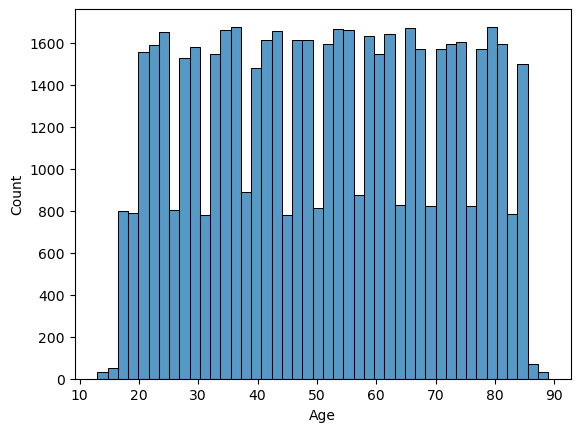

In [20]:
sns.histplot(data=df, x="Age")

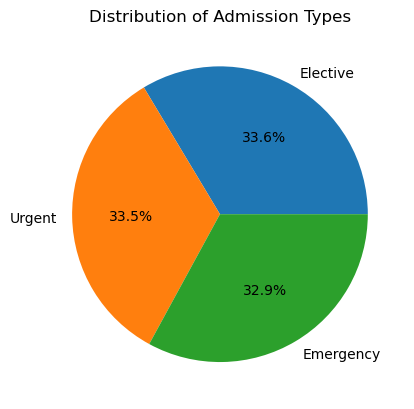

In [21]:
df["Admission Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Distribution of Admission Types")
plt.show()

<Axes: xlabel='Medical Condition', ylabel='Billing Amount'>

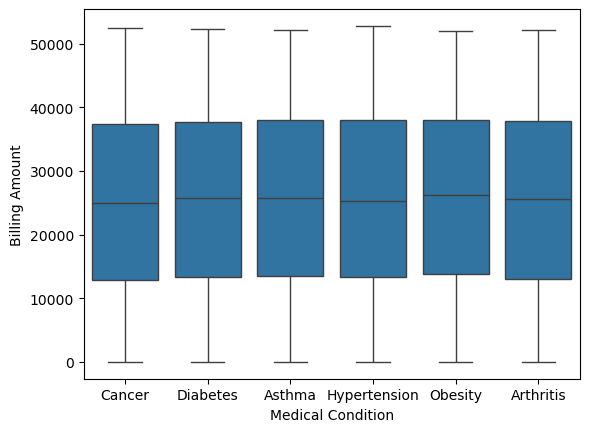

In [22]:
sns.boxplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

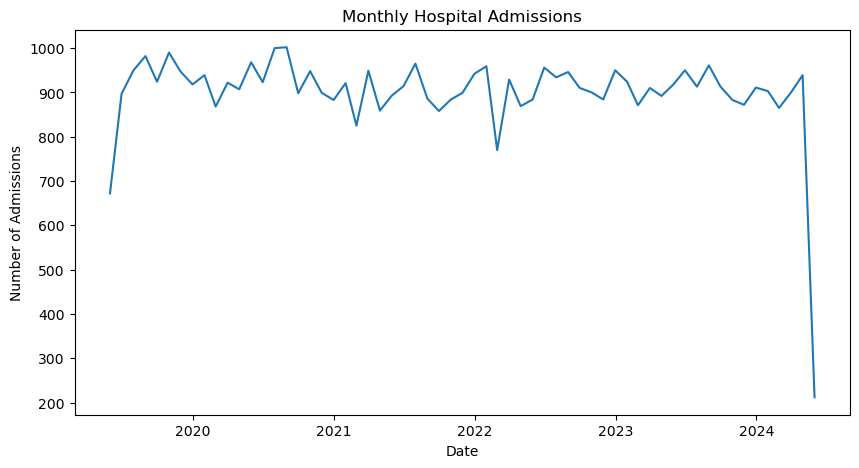

In [24]:
monthly_admissions = (
    df.set_index("Date of Admission")
      .resample("ME")
      .size()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    
)

plt.title("Monthly Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")

plt.show()